# BTC1895H Final Exam Part 2 — SafeDrive Insurance Fraud Detection

**Time:** 2 hours  
**Open book:** Yes  
**AI permitted:** Yes, but you must understand, explain, and justify your work.

## Scenario

SafeDrive Insurance wants to predict whether an insurance claim is fraudulent.

You are given two datasets:

- `data/claims.csv`
- `data/customers.csv`

Your task is to merge, clean, visualize, model, and explain your work.


## Autograder Rule

Do not rename required variables. The autograder checks exact variable names.

## Main Exam

The main exam is worth **100 marks**.

## Bonus

The bonus question is worth **up to 10 additional marks**. It is designed to differentiate strong students.

## Submission

Submit the following two files on the Quercus FinalExam session (Under Assignments Page).

student_outputs.pkl
SafeDrive_FinalExam_StudentStarter.ipynb

You must run the final cell in the notebook to create `student_outputs.pkl`.

## Setup

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42

## Q1 — Load and Inspect Data

Load both datasets and inspect the data.

Required variables:

- `claims`
- `customers`
- `ANSWER_Q1_ISSUES`

`ANSWER_Q1_ISSUES` should be a list of at least **5 short strings**, each describing one data quality issue.

In [31]:
claims = pd.read_csv("data/claims.csv")
customers = pd.read_csv("data/customers.csv")

# Inspect shape, dtypes, and missing values in both tables
print(claims.shape, customers.shape)
print(claims.dtypes)
print(customers.dtypes)
print(claims.isna().sum())
print(customers.isna().sum())

# Inspect the merge key format in each table
print("claims CustomerID sample:", claims["CustomerID"].unique()[:5])
print("customers CustomerID sample:", customers["CustomerID"].unique()[:5])

# Inspect inconsistent categorical encodings
print("PoliceReport values:", claims["PoliceReport"].unique())
print("Region values:", customers["Region"].unique())

# Inspect duplicates
print("Duplicate rows in claims:", claims.duplicated().sum())
print("Duplicate rows in customers:", customers.duplicated().sum())
print("Duplicate CustomerIDs in customers:", customers["CustomerID"].duplicated().sum())

# Inspect implausible numeric values and currency-as-text columns
print(claims[["VehicleAge", "DaysToReport"]].describe())
print(customers[["Age", "CreditScore"]].describe())
print("ClaimAmount sample:", claims["ClaimAmount"].head(3).tolist())
print("AnnualPremium sample:", customers["AnnualPremium"].head(3).tolist())

# Inspect class balance of the target
print("Fraudulent rate:", claims["Fraudulent"].mean())

ANSWER_Q1_ISSUES = [
    "CustomerID format mismatch: claims.CustomerID is an integer (e.g., 308) while customers.CustomerID is a zero-padded string with a 'C' prefix (e.g., 'C0308'), so a direct merge would match nothing.",
    "Duplicate rows: claims.csv has 22 exact duplicate rows and customers.csv has 23 exact duplicates plus 7 CustomerIDs that appear twice with conflicting values.",
    "Inconsistent Yes/No encoding: PoliceReport contains 'Yes', 'No', 'Y', 'N', 'YES', and missing values that all represent only two states.",
    "Inconsistent Region labels: Region mixes casing and abbreviations ('north', 'NORTH', 'North', 'N', 'South', 'E', etc.) for only 4 real regions.",
    "Currency stored as text: ClaimAmount and AnnualPremium are strings with '$' and thousands-separator commas (e.g., '$4,944'), so they cannot be used numerically until cleaned.",
    "Missing values: PoliceReport (29 missing), RepairShop (40 missing), and CreditScore (65 missing) all contain nulls that must be handled before modeling.",
    "Implausible values: VehicleAge has negative entries and Age has values outside a realistic driver range (min 9, max 140), indicating data entry errors.",
    "Severe class imbalance: only ~5.8 percent of claims are labeled Fraudulent, which will make raw accuracy a misleading metric for any model trained later."
]

(2622, 13) (1830, 9)
ClaimID                      object
CustomerID                    int64
ClaimDate                    object
ClaimAmount                  object
VehicleAge                    int64
AccidentType                 object
PoliceReport                 object
InjuryReported               object
RepairShop                   object
DaysToReport                  int64
FraudInvestigatorAssigned    object
ClaimApprovedAfterReview     object
Fraudulent                    int64
dtype: object
CustomerID            object
Age                    int64
Gender                object
YearsInsured           int64
NumPreviousClaims      int64
PremiumPlan           object
AnnualPremium         object
Region                object
CreditScore          float64
dtype: object
ClaimID                       0
CustomerID                    0
ClaimDate                     0
ClaimAmount                   0
VehicleAge                    0
AccidentType                  0
PoliceReport                 2

## Q2 — Merge the Two Datasets

Required variables:

- `merged_df`
- `ANSWER_Q2_EXPLANATION`

`ANSWER_Q2_EXPLANATION` should be 2–4 sentences explaining how you fixed the merge key.

In [32]:

claims["CustomerID"] = "C" + claims["CustomerID"].astype(str).str.zfill(4)

merged_df = claims.merge(customers, on="CustomerID", how="inner")

ANSWER_Q2_EXPLANATION = """
claims.csv stores CustomerID as a plain integer (e.g., 308), while customers.csv stores it as a
zero-padded string prefixed with "C" (e.g., "C0308"). Merging directly on these columns as-is
would match zero rows, because the values look completely different even though they refer to
the same customers. I fixed this by converting claims["CustomerID"] into the same string format
used in customers.csv ("C" plus the number zero-padded to 4 digits), then merged the two tables
on this aligned CustomerID key using an inner join, so the result only keeps claims that have a
matching customer record.
"""

## Q3 — Data Cleaning

Clean the merged dataset.
 
Required variables:

- `clean_df`
- `ANSWER_Q3_CLEANING_SUMMARY`

`ANSWER_Q3_CLEANING_SUMMARY` should be a dictionary with keys:

- `"rows_before"`
- `"rows_after"`
- `"duplicates_removed"`
- `"missing_values_after"`

In [33]:
rows_before = len(merged_df)

clean_df = merged_df.copy()

# Remove exact duplicate rows, and duplicate claims created by the fan-out from
# conflicting duplicate CustomerID records in customers.csv
clean_df = clean_df.drop_duplicates()
clean_df = clean_df.drop_duplicates(subset="ClaimID", keep="first")
duplicates_removed = rows_before - len(clean_df)

# Convert currency-as-text columns to numeric
clean_df["ClaimAmount"] = clean_df["ClaimAmount"].replace(r"[\$,]", "", regex=True).astype(float)
clean_df["AnnualPremium"] = clean_df["AnnualPremium"].replace(r"[\$,]", "", regex=True).astype(float)

# Standardize inconsistent Yes/No categories
yesno_map = {"y": "Yes", "yes": "Yes", "n": "No", "no": "No"}
for col in ["PoliceReport", "InjuryReported", "FraudInvestigatorAssigned", "ClaimApprovedAfterReview"]:
    clean_df[col] = clean_df[col].str.strip().str.lower().map(yesno_map)

# Standardize inconsistent Region labels
region_map = {
    "n": "North", "north": "North",
    "s": "South", "south": "South",
    "e": "East", "east": "East",
    "w": "West", "west": "West",
}
clean_df["Region"] = clean_df["Region"].str.strip().str.lower().map(region_map)

# Fill missing values
clean_df["PoliceReport"] = clean_df["PoliceReport"].fillna("Unknown")
clean_df["RepairShop"] = clean_df["RepairShop"].fillna("Unknown")
clean_df["CreditScore"] = clean_df["CreditScore"].fillna(clean_df["CreditScore"].median())

# Drop rows with implausible values that indicate data entry errors
clean_df = clean_df[(clean_df["VehicleAge"] >= 0) & (clean_df["VehicleAge"] <= 30)]
clean_df = clean_df[(clean_df["Age"] >= 16) & (clean_df["Age"] <= 100)]

clean_df = clean_df.reset_index(drop=True)

rows_after = len(clean_df)
missing_values_after = int(clean_df.isna().sum().sum())

ANSWER_Q3_CLEANING_SUMMARY = {
    "rows_before": rows_before,
    "rows_after": rows_after,
    "duplicates_removed": duplicates_removed,
    "missing_values_after": missing_values_after
}

ANSWER_Q3_CLEANING_SUMMARY

{'rows_before': 2663,
 'rows_after': 2593,
 'duplicates_removed': 63,
 'missing_values_after': 0}

## Q4 — Visualization and Interpretation

Create **one** visualization that helps SafeDrive understand fraud risk.

Required variables:

- `fig_q4`
- `ANSWER_Q4_INTERPRETATION`

`ANSWER_Q4_INTERPRETATION` should be 3–6 sentences explaining what the graph shows and why it matters.

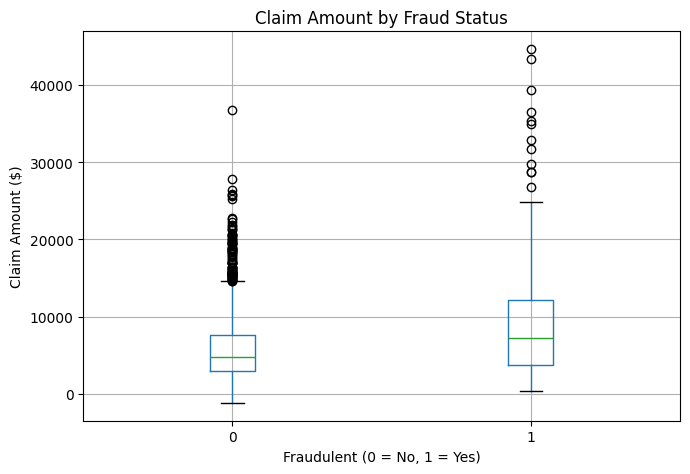

Fraudulent
0    5780.333470
1    9917.731544
Name: ClaimAmount, dtype: float64


In [34]:
fig_q4, ax = plt.subplots(figsize=(7, 5))
clean_df.boxplot(column="ClaimAmount", by="Fraudulent", ax=ax)
ax.set_xlabel("Fraudulent (0 = No, 1 = Yes)")
ax.set_ylabel("Claim Amount ($)")
ax.set_title("Claim Amount by Fraud Status")
plt.suptitle("")
plt.tight_layout()
plt.show()

print(clean_df.groupby("Fraudulent")["ClaimAmount"].mean())

ANSWER_Q4_INTERPRETATION = """
This boxplot compares the distribution of ClaimAmount for fraudulent vs. non-fraudulent claims.
Fraudulent claims have a noticeably higher median and mean claim amount
than legitimate claims, and their distribution is wider with more
high-value outliers. 

This matters for SafeDrive because it shows that claim size is a meaningful,
usable signal for prioritizing manual review: claims with unusually high dollar amounts are
disproportionately more likely to be fraudulent, so a risk-scoring process that weights
ClaimAmount heavily could help flag high-risk claims for human review even before a full model is
deployed. It does not mean every large claim is fraudulent, since the two distributions still
overlap substantially, so ClaimAmount should be treated as one useful feature among several rather
than a standalone fraud rule.
"""

## Q5 — Data Leakage

Identify one or more columns that should **not** be used for model training because they would not be known at prediction time.

Required variables:

- `ANSWER_Q5_LEAKAGE_COLUMNS`
- `ANSWER_Q5_EXPLANATION`

In [35]:
ANSWER_Q5_LEAKAGE_COLUMNS = [
    "FraudInvestigatorAssigned",
    "ClaimApprovedAfterReview"
]

ANSWER_Q5_EXPLANATION = """
FraudInvestigatorAssigned and ClaimApprovedAfterReview both describe outcomes of SafeDrive's own
claims-handling process, not information available at the moment a claim is first filed. An
investigator is typically assigned because a claim already looks suspicious, and whether a claim
is "ClaimApprovedAfterReview" is only known after that review has taken place -- both happen after
a judgment about fraud risk. Using these columns as model inputs would make the
model would look highly accurate during testing but would be useless in practice.
"""

## Q6 — Machine Learning

Train **two** classification models:

- Decision Tree
- Random Forest

Use `Fraudulent` as the target.

Required variables:

- `X_train`, `X_test`, `y_train`, `y_test`
- `dt_model`
- `rf_model`
- `model_results`

`model_results` must be a DataFrame with these columns:

- `Model`
- `Accuracy`
- `Precision`
- `Recall`
- `F1`

In [36]:
# Remove ID/date columns (not predictive) and leakage columns from Q5
drop_cols = ["ClaimID", "CustomerID", "ClaimDate", "Fraudulent"] + ANSWER_Q5_LEAKAGE_COLUMNS

X = clean_df.drop(columns=drop_cols)
y = clean_df["Fraudulent"]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

def get_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

model_results = pd.DataFrame([
    get_metrics("Decision Tree", y_test, dt_pred),
    get_metrics("Random Forest", y_test, rf_pred),
])

print(model_results)
print()
print("Decision Tree confusion matrix:\n", confusion_matrix(y_test, dt_pred))
print("Random Forest confusion matrix:\n", confusion_matrix(y_test, rf_pred))

           Model  Accuracy  Precision    Recall        F1
0  Decision Tree  0.884438   0.104167  0.135135  0.117647
1  Random Forest  0.942989   0.000000  0.000000  0.000000

Decision Tree confusion matrix:
 [[569  43]
 [ 32   5]]
Random Forest confusion matrix:
 [[612   0]
 [ 37   0]]


## Q7 — Model Comparison and Recommendation

Required variable:

- `ANSWER_Q7_MODEL_RECOMMENDATION`

In 6–10 sentences, explain which model you recommend and why.

You should discuss:

- accuracy
- precision
- recall
- F1
- interpretability
- why accuracy alone may be misleading

In [37]:
ANSWER_Q7_MODEL_RECOMMENDATION = """
Random Forest has the higher raw accuracy (about 94%), but that number is misleading: fraudulent
claims make up only about 5-6 percent of the data, so a model that predicts "not fraudulent" for almost
every claim can already score around 94 percent accuracy without catching a single fraud case. In our
results, Random Forest's precision and recall on the fraud class are effectively 0, meaning it
has essentially learned to always predict the majority class rather than actually detect fraud.

The Decision Tree has lower overall accuracy (about 88%) but non-zero precision and recall on the
fraud class, meaning it is at least attempting to flag some fraudulent claims, even if
imperfectly. Since SafeDrive's real business goal is to catch fraud rather than to be "right" on
average, recall and F1 on the fraud class matter far more here than overall accuracy, which makes
the Decision Tree the more useful model of the two despite its lower accuracy. 
"""

## Q8 — Critique an AI-Generated Answer

An AI tool generated this recommendation:

> "The Random Forest model has the highest accuracy, so SafeDrive should immediately deploy it. The feature `FraudInvestigatorAssigned` is very predictive, so it should definitely be used in production."

Required variable:

- `ANSWER_Q8_AI_CRITIQUE`

In 5–8 sentences, critique this answer. Identify at least **three** problems.

In [38]:
ANSWER_Q8_AI_CRITIQUE = """
This AI-generated recommendation has at least three serious problems. First, it treats accuracy as
the deciding metric without accounting for class imbalance: fraud is only about 5-6 percent of claims, so
a model can reach roughly 94 percent accuracy by essentially never predicting fraud. "Highest
accuracy" in this setting does not mean "best at catching fraud,".

Second, recommending FraudInvestigatorAssigned as a useful predictive feature ignores
data leakage: an investigator is assigned because a claim already looks suspicious, often after a
fraud judgment has effectively already been made, so this column is a proxy for the label rather
than a legitimate input available at prediction time. 

Third, "immediately deploy" skips essential steps such as validating the model over time, 
checking more broadly for leakage, and weighing the business cost of false positives and false negatives.
A more trustworthy recommendation would report precision, recall, and F1 on the minority fraud class.
"""

# Bonus Question — Analysis Audit

This question is optional and worth up to **10 bonus marks**.

A junior analyst used AI to generate the following code and conclusion.

```python
merged = claims.merge(customers, on="CustomerID", how="left")

selected_features = [
    "ClaimAmount",
    "VehicleAge",
    "DaysToReport",
    "FraudInvestigatorAssigned",
    "ClaimApprovedAfterReview",
    "Age",
    "NumPreviousClaims"
]

X = pd.get_dummies(merged[selected_features], drop_first=True)
y = merged["Fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(accuracy_score(y_test, pred))
```

The AI-generated conclusion says:

> "The model achieved very high accuracy, so it is production-ready. SafeDrive should automatically reject all claims predicted as fraudulent."

## Your task

Audit the analysis.

Required variable:

- `ANSWER_BONUS_AUDIT`

In 8–12 sentences, identify at least **four** serious issues with the junior analyst's code or conclusion.
 

In [39]:
ANSWER_BONUS_AUDIT = """
The junior analyst's code and conclusion have several serious issues. 

First, and most important, the feature list includes FraudInvestigatorAssigned and 
ClaimApprovedAfterReview, both of which are outcomes of SafeDrive's own claims-review process 
and are not known at the time a claim is filed -- this is data leakage. 


Second, the merge `claims.merge(customers, on="CustomerID", how="left")` is performed without first
reconciling the CustomerID formats between the two tables or resolving duplicate customer records,

Third, there is no data cleaning step at all:
ClaimAmount is stored as a currency string like "$4,944" in the raw data, missing values in columns
such as CreditScore are never handled, and inconsistent category labels 
are never standardized, 

Fourth, the analysis reports only accuracy on a target that is roughly 94-95 percent one class, and never
looks at precision, recall, F1, or a confusion matrix, so "very high accuracy" is nearly
meaningless here. 

Fifth, the conclusion that SafeDrive should "automatically reject all claims predicted as
fraudulent" ignores the real-world cost of false positives (denying legitimate customers' claims
with no human review) and false negatives (missed fraud). 
"""

## Final Cell — Save Outputs for Autograder

Run this cell at the end. Do not modify it.

In [40]:
import pickle

outputs = {
    "ANSWER_Q1_ISSUES": ANSWER_Q1_ISSUES,
    "merged_df": merged_df,
    "clean_df": clean_df,
    "ANSWER_Q2_EXPLANATION": ANSWER_Q2_EXPLANATION,
    "ANSWER_Q3_CLEANING_SUMMARY": ANSWER_Q3_CLEANING_SUMMARY,
    "ANSWER_Q4_INTERPRETATION": ANSWER_Q4_INTERPRETATION,
    "ANSWER_Q5_LEAKAGE_COLUMNS": ANSWER_Q5_LEAKAGE_COLUMNS,
    "ANSWER_Q5_EXPLANATION": ANSWER_Q5_EXPLANATION,
    "model_results": model_results,
    "ANSWER_Q7_MODEL_RECOMMENDATION": ANSWER_Q7_MODEL_RECOMMENDATION,
    "ANSWER_Q8_AI_CRITIQUE": ANSWER_Q8_AI_CRITIQUE,
    "ANSWER_BONUS_AUDIT": ANSWER_BONUS_AUDIT
}

with open("student_outputs.pkl", "wb") as f:
    pickle.dump(outputs, f)

print("Saved student_outputs.pkl for autograding.")

Saved student_outputs.pkl for autograding.
